# 🧠 SECTION 1 — PROBLEM STATEMENT

# Decision Tree Classification — Titanic Survival Prediction

## Problem Statement

The objective of this project is to build a machine learning model
that predicts whether a passenger survived the Titanic disaster.

The target variable is `Survived`.

This is a binary classification problem where:

- 0 = Did not survive

- 1 = Survived

A Decision Tree classifier will be trained and evaluated using
appropriate classification metrics.

# 📊 SECTION 2 — DATASET ANALYSIS

In [160]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#### Load the dataset:

In [161]:
df = pd.read_csv("../dataset/titanic/train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Check shape

In [162]:
df.shape

(891, 12)

#### Check columns

In [163]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

#### Check data types

In [164]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

#### Check missing values

In [165]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### Basic statistics

In [166]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### Target distribution

In [167]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# 🧹 SECTION 3 — DATA CLEANING

First remove columns that are not useful for this particular model.

In [168]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

Then inspect again:

In [169]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Check missing values:

In [170]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Do not simply fill missing values before splitting the dataset.

This is important because preprocessing statistics should be learned from the training data rather than the test data.

# 🎯 SECTION 4 — DEFINE X AND y

In [171]:
X = df.drop(columns="Survived")
y = df["Survived"]

#### Check:

In [172]:
X.shape, y.shape

((891, 7), (891,))

# ✂️ SECTION 5 — TRAIN/TEST SPLIT

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

Why stratify=y?

Because this is a classification problem.

It helps preserve the class distribution between training and testing data.

# ⚙️ SECTION 6 — PREPROCESSING

Identify numerical and categorical features.

In [174]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

Create numerical preprocessing:

In [175]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

Categorical preprocessing:

In [176]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

Combine them:

In [177]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 🌳 SECTION 7 — BASELINE DECISION TREE

Now train your first Decision Tree.

In [178]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

Train:

In [179]:
baseline_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Predict:

In [180]:
y_pred = baseline_model.predict(X_test)

# 📈 SECTION 8 — EVALUATION

In [181]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print(cm)
print(classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587
Precision: 0.78125
Recall: 0.7246376811594203
F1 Score: 0.7518796992481203
[[96 14]
 [19 50]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



### Evaluation Interpretation

Accuracy measures the proportion of correct predictions.

Precision measures how many predicted positive cases were
actually positive.

Recall measures how many actual positive cases were correctly
identified.

F1 score provides a balance between precision and recall.

The confusion matrix shows the counts of true positives,
true negatives, false positives, and false negatives.

# 🔬 SECTION 9 — HYPERPARAMETER EXPERIMENT

This is one of the most important parts of today's project.

### Test:

max_depth = 1

max_depth = 2

max_depth = 3

max_depth = 5

max_depth = 10

### Create:

In [182]:
depths = [1, 2, 3, 5, 10]

results = []

for depth in depths:

    model = Pipeline(
        steps = [
            ("preprocessor", preprocessor),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth = depth,
                    random_state = 42
                )
            )
        ]
    )

    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results.append({
        "max_depth": depth,
        "train_score":train_score,
        "test_score":test_score
    })

results_df = pd.DataFrame(results)

results_df

,max_depth,train_score,test_score
0,1,0.789326,0.776536
1,2,0.804775,0.759777
2,3,0.832865,0.793296
3,5,0.865169,0.759777
4,10,0.945225,0.793296


### 📊 VISUALIZE THE EXPERIMENT

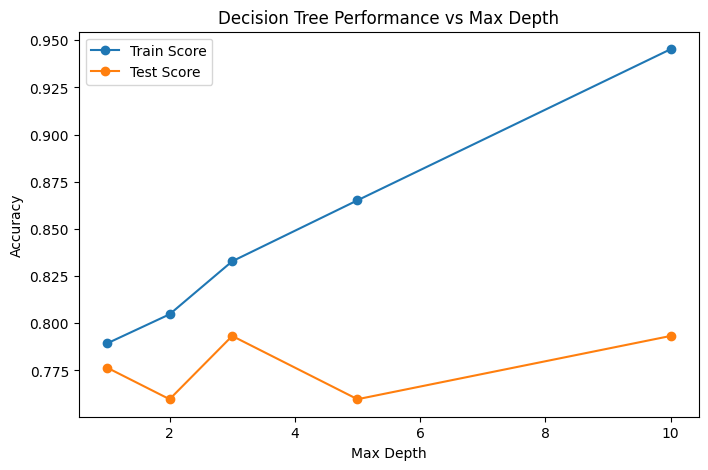

In [183]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["max_depth"],
    results_df["train_score"],
    marker = "o",
    label = "Train Score"
)

plt.plot(
    results_df["max_depth"],
    results_df["test_score"],
    marker = "o",
    label = "Test Score"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Performance vs Max Depth")
plt.legend()
plt.show()

# 🌳 SECTION 11 — FEATURE IMPORTANCE

Train a final candidate model.

In [184]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

final_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Now retrieve the trained tree:

In [185]:
tree_model = final_model.named_steps["model"]

tree_model.feature_importances_

array([0.12175019, 0.01115009, 0.00771396, 0.11407568, 0.0480862 ,
       0.        , 0.1323173 , 0.53065474, 0.        , 0.        ,
       0.        , 0.03425184])

#### However, because we used OneHotEncoder, the original feature names have been transformed.

#### Get the transformed feature names:

In [186]:
feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

### Create a table:

In [187]:
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df

,feature,importance
7,cat__Sex_female,0.530655
6,cat__Pclass_3,0.132317
0,num__Age,0.121750
3,num__Fare,0.114076
4,cat__Pclass_1,0.048086
11,cat__Embarked_S,0.034252
1,num__SibSp,0.011150
2,num__Parch,0.007714
5,cat__Pclass_2,0.000000
8,cat__Sex_male,0.000000


### 📊 VISUALIZE FEATURE IMPORTANCE

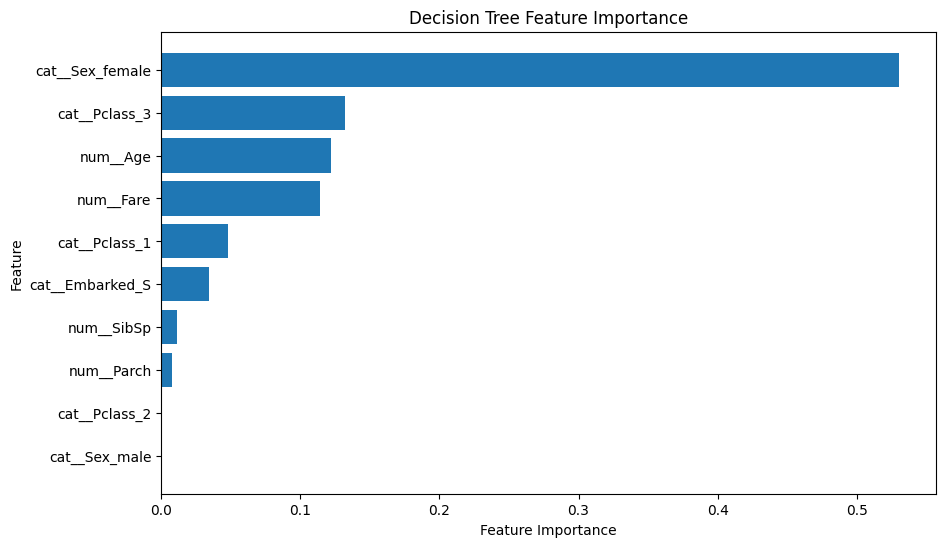

In [188]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.show()

# 🏁 SECTION 12 — FINAL MODEL EVALUATION

In [189]:
y_pred_final = final_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

print(classification_report(y_test, y_pred_final))

Accuracy : 0.7597765363128491
Precision: 0.7407407407407407
Recall   : 0.5797101449275363
F1 Score : 0.6504065040650406
[[96 14]
 [29 40]]
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.74      0.58      0.65        69

    accuracy                           0.76       179
   macro avg       0.75      0.73      0.73       179
weighted avg       0.76      0.76      0.75       179

